# Task 1: ML Classification Project
**Alfido Tech Internship Program - Artificial Intelligence Track**

**Goal:** Build and evaluate a supervised classification model.

**Problem:** Predict whether a breast tumour is **malignant** or **benign** from 30 numeric features computed from digitised images of a fine-needle aspirate (Breast Cancer Wisconsin Diagnostic dataset, bundled with scikit-learn, 569 samples).

**Requirements covered**
1. Data preprocessing, train/test split, cross-validation
2. Comparison of at least two algorithms (Logistic Regression, Random Forest, plus SVM and Gradient Boosting)
3. Metrics: accuracy, precision, recall, F1, ROC-AUC

**Convention:** the *positive class (1) = malignant*, so recall answers "of all real cancers, how many did we catch?".

In [1]:
import os, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)
from sklearn.inspection import permutation_importance

SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

# Project root works whether run from notebooks/, src/ or the repo root
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name in ("notebooks", "src") else cwd
for d in ("images", "results", "models", "data"):
    (ROOT / d).mkdir(exist_ok=True)

print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4


## 1. Load data and inspect

In [2]:
raw = load_breast_cancer(as_frame=True)
df = raw.frame.copy()

# In scikit-learn, target 0 = malignant, 1 = benign. Flip so that 1 = malignant (positive class).
df["target"] = (df["target"] == 0).astype(int)
df["diagnosis"] = df["target"].map({1: "malignant", 0: "benign"})

print("Shape:", df.shape)
print("\nClass balance:")
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True).round(3))
df.head()

Shape: (569, 32)

Class balance:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64
diagnosis
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,malignant


## 2. Data preprocessing and cleaning
Checks for missing values, duplicates and wrong data types. Scaling is done **inside the model pipeline** (fitted on training folds only) to avoid data leakage.

In [3]:
print("Missing values (total):", int(df.isna().sum().sum()))
print("Duplicate rows        :", int(df.drop(columns='diagnosis').duplicated().sum()))
print("Non-numeric features  :", [c for c in df.columns if c not in ('diagnosis',) and not np.issubdtype(df[c].dtype, np.number)])

# Cleaning step (no-ops on this dataset but kept so the pipeline is reusable on messier data)
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

df.drop(columns="diagnosis").to_csv(ROOT / "data" / "breast_cancer.csv", index=False)
df.drop(columns=["diagnosis", "target"]).describe().T.head(10).round(3)

Missing values (total): 0
Duplicate rows        : 0
Non-numeric features  : []


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


## 3. Exploratory data analysis

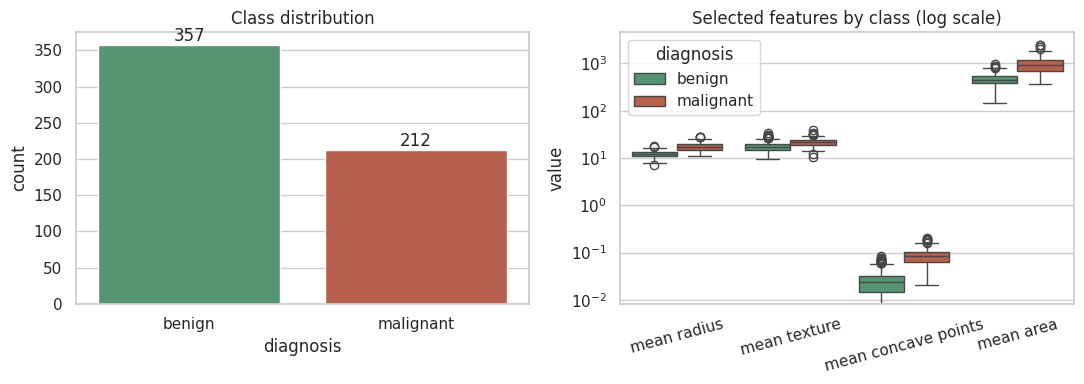

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
order = ["benign", "malignant"]
sns.countplot(data=df, x="diagnosis", order=order, palette=["#4C9F70", "#C8553D"], ax=ax[0])
ax[0].set_title("Class distribution")
for p in ax[0].patches:
    ax[0].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")

feats = ["mean radius", "mean texture", "mean concave points", "mean area"]
melted = df.melt(id_vars="diagnosis", value_vars=feats)
sns.boxplot(data=melted, x="variable", y="value", hue="diagnosis", hue_order=order,
            palette=["#4C9F70", "#C8553D"], ax=ax[1])
ax[1].set_yscale("log"); ax[1].set_xlabel(""); ax[1].set_title("Selected features by class (log scale)")
ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(ROOT / "images" / "01_class_and_features.png", dpi=150)
plt.show()

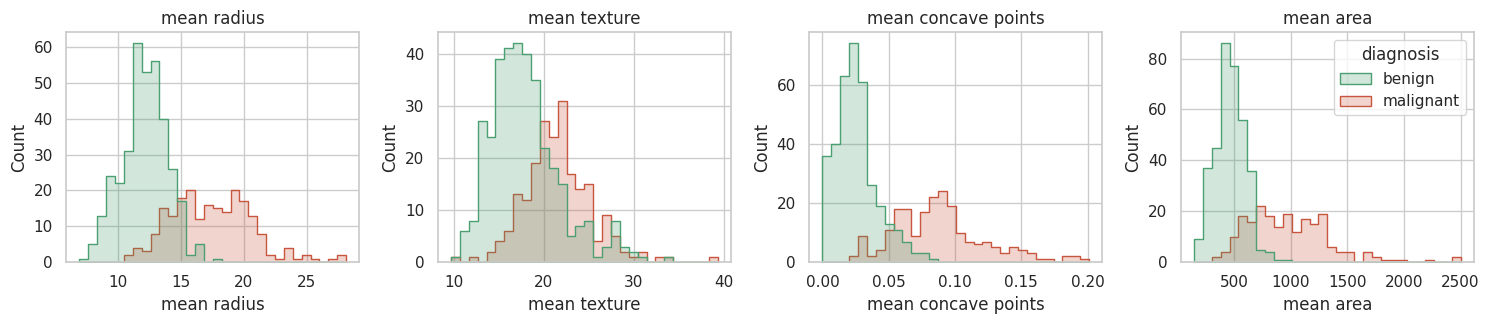

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for a, f in zip(axes, feats):
    sns.histplot(data=df, x=f, hue="diagnosis", hue_order=order, palette=["#4C9F70", "#C8553D"],
                 bins=30, element="step", ax=a, legend=(a is axes[-1]))
    a.set_title(f)
plt.tight_layout()
plt.savefig(ROOT / "images" / "02_histograms.png", dpi=150)
plt.show()

Top 5 features most correlated with malignancy:
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
Name: target, dtype: float64


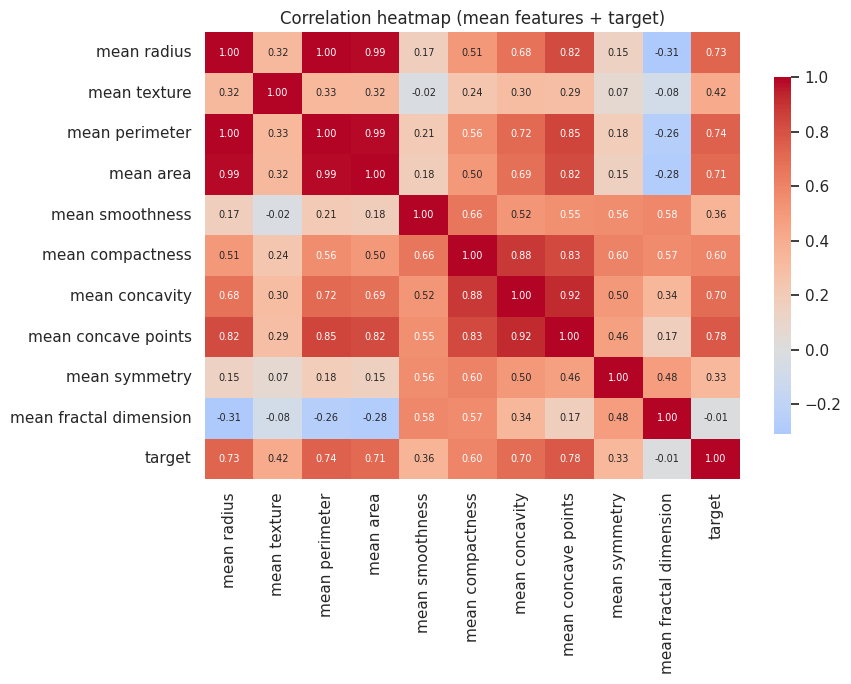

In [6]:
mean_cols = [c for c in df.columns if c.startswith("mean ")]
corr = df[mean_cols + ["target"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Correlation heatmap (mean features + target)")
plt.tight_layout()
plt.savefig(ROOT / "images" / "03_correlation_heatmap.png", dpi=150)
plt.show()

print("Top 5 features most correlated with malignancy:")
print(df.drop(columns="diagnosis").corr()["target"].drop("target").abs().sort_values(ascending=False).head(5).round(3))

## 4. Train / test split
80 / 20 **stratified** split, so both sets keep the same malignant/benign ratio. The test set is touched only once, for the final evaluation.

In [7]:
X = df.drop(columns=["target", "diagnosis"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print(f"Train: {X_train.shape}  malignant share = {y_train.mean():.3f}")
print(f"Test : {X_test.shape}  malignant share = {y_test.mean():.3f}")

Train: (455, 30)  malignant share = 0.374
Test : (114, 30)  malignant share = 0.368


## 5. Compare algorithms with 5-fold stratified cross-validation
Four algorithms are compared on the **training set only**. Scaling sits inside each pipeline so it is fitted on the training folds only.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=5000, random_state=SEED))]),
    "Random Forest":       Pipeline([("clf", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))]),
    "SVM (RBF)":           Pipeline([("scaler", StandardScaler()),
                                     ("clf", SVC(probability=True, random_state=SEED))]),
    "Gradient Boosting":   Pipeline([("clf", GradientBoostingClassifier(random_state=SEED))]),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_rows, cv_raw = [], {}
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_raw[name] = res
    row = {"Model": name}
    for m in scoring:
        row[m] = f"{res['test_' + m].mean():.3f} +/- {res['test_' + m].std():.3f}"
    cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).set_index("Model")
cv_table.to_csv(ROOT / "results" / "cv_comparison.csv")
cv_table

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.974 +/- 0.015,0.977 +/- 0.028,0.953 +/- 0.040,0.964 +/- 0.021,0.996 +/- 0.005
Random Forest,0.960 +/- 0.016,0.958 +/- 0.022,0.935 +/- 0.039,0.946 +/- 0.023,0.988 +/- 0.007
SVM (RBF),0.971 +/- 0.005,0.977 +/- 0.021,0.947 +/- 0.034,0.961 +/- 0.008,0.995 +/- 0.005
Gradient Boosting,0.967 +/- 0.014,0.965 +/- 0.021,0.947 +/- 0.034,0.955 +/- 0.020,0.991 +/- 0.006


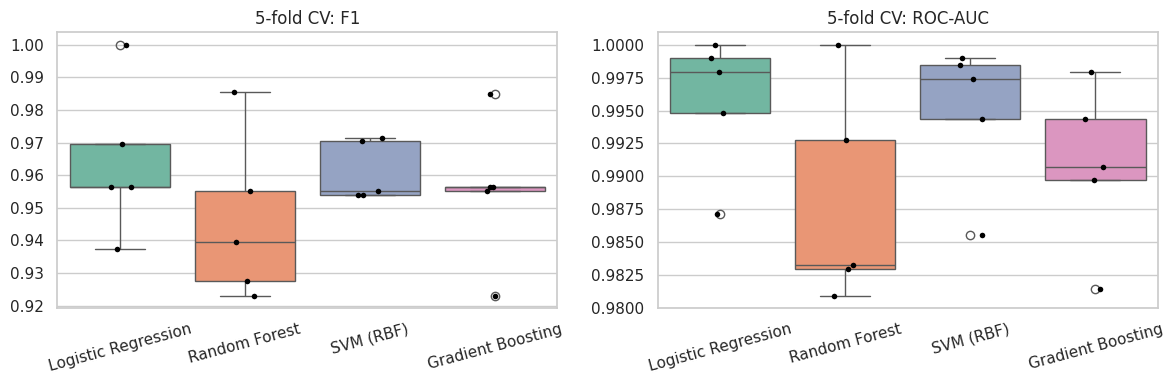

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, metric in zip(ax, ["f1", "roc_auc"]):
    data = pd.DataFrame({n: r["test_" + metric] for n, r in cv_raw.items()})
    sns.boxplot(data=data, ax=a, palette="Set2")
    sns.stripplot(data=data, ax=a, color="black", size=4)
    a.set_title(f"5-fold CV: {metric.upper() if metric=='f1' else 'ROC-AUC'}")
    a.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(ROOT / "images" / "04_cv_comparison.png", dpi=150)
plt.show()

## 6. Hyper-parameter tuning (GridSearchCV)
Each model gets a small grid, tuned on the **training set** with 5-fold CV, optimising **F1**. F1 is used because it balances precision and recall, and a missed malignancy (false negative) is the costlier error here.

In [10]:
param_grids = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10, 100]},
    "Random Forest":       {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 6, 12],
                            "clf__min_samples_leaf": [1, 3]},
    "SVM (RBF)":           {"clf__C": [0.1, 1, 10, 100], "clf__gamma": ["scale", 0.01, 0.001]},
    "Gradient Boosting":   {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.05, 0.1],
                            "clf__max_depth": [2, 3]},
}

tuned, tune_rows = {}, []
for name, pipe in models.items():
    gs = GridSearchCV(pipe, param_grids[name], cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    tune_rows.append({"Model": name, "Best CV F1": round(gs.best_score_, 4),
                      "Best params": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()}})

tune_table = pd.DataFrame(tune_rows).set_index("Model")
tune_table.to_csv(ROOT / "results" / "tuning_results.csv")
tune_table

,Best CV F1,Best params
Model,,
Logistic Regression,0.9640,{'C': 1}
Random Forest,0.9516,"{'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 200}"
SVM (RBF),0.9674,"{'C': 10, 'gamma': 'scale'}"
Gradient Boosting,0.9645,"{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}"


## 7. Final evaluation on the held-out test set
All tuned models are scored once on the 114 unseen test samples with accuracy, precision, recall, F1 and ROC-AUC.

In [11]:
def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {"Accuracy": accuracy_score(y_te, pred), "Precision": precision_score(y_te, pred),
            "Recall": recall_score(y_te, pred), "F1": f1_score(y_te, pred),
            "ROC-AUC": roc_auc_score(y_te, proba)}

test_table = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in tuned.items()}).T.round(4)
test_table.to_csv(ROOT / "results" / "test_metrics.csv")
test_table

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960
Random Forest,0.9649,1.000,0.9048,0.9500,0.9947
SVM (RBF),0.9737,1.000,0.9286,0.9630,0.9927
Gradient Boosting,0.9649,1.000,0.9048,0.9500,0.9934


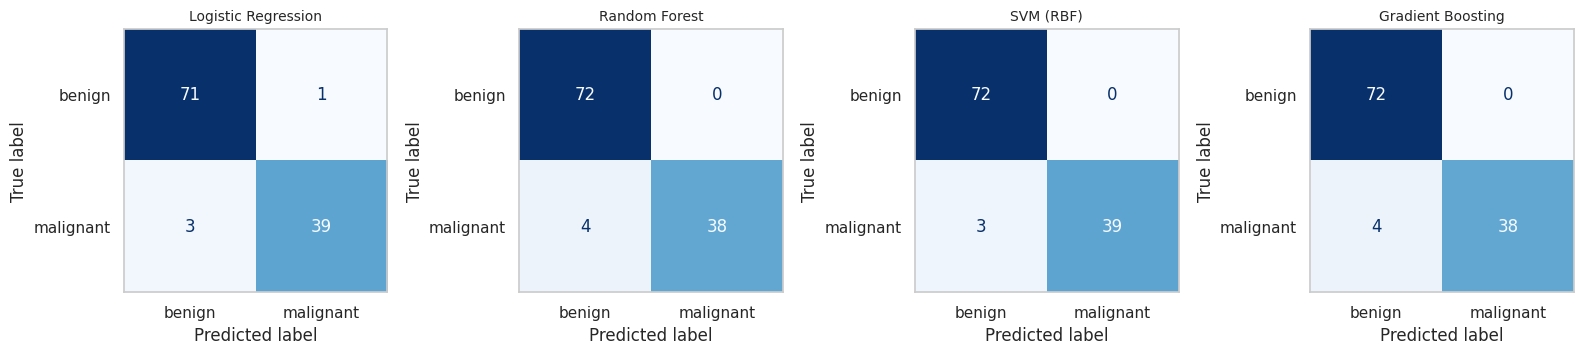

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for a, (name, m) in zip(axes, tuned.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, display_labels=["benign", "malignant"],
                                          cmap="Blues", colorbar=False, ax=a)
    a.set_title(name, fontsize=10); a.grid(False)
plt.tight_layout()
plt.savefig(ROOT / "images" / "05_confusion_matrices.png", dpi=150)
plt.show()

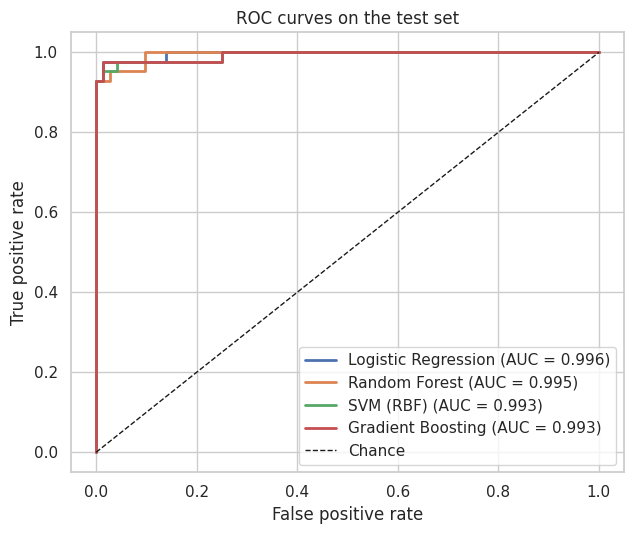

In [13]:
plt.figure(figsize=(6.5, 5.5))
for name, m in tuned.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves on the test set"); plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ROOT / "images" / "06_roc_curves.png", dpi=150)
plt.show()

## 8. Model selection
The final model is chosen by **best cross-validated F1 on the training data** (not by test score), so the test set stays an unbiased estimate. Ties are broken by the highest CV ROC-AUC of the tuned model.

In [14]:
sel = []
for name, m in tuned.items():
    r = cross_validate(m, X_train, y_train, cv=cv, scoring=["f1", "roc_auc"], n_jobs=-1)
    sel.append({"Model": name, "CV F1": r["test_f1"].mean(), "CV ROC-AUC": r["test_roc_auc"].mean()})
sel = pd.DataFrame(sel).set_index("Model").round(4).sort_values(["CV F1", "CV ROC-AUC"], ascending=False)

best_name = sel.index[0]
best_model = tuned[best_name]
print("Selected model:", best_name)
sel

Selected model: SVM (RBF)


,CV F1,CV ROC-AUC
Model,,
SVM (RBF),0.9674,0.9935
Gradient Boosting,0.9645,0.9932
Logistic Regression,0.9640,0.9958
Random Forest,0.9516,0.9883


In [15]:
best_pred = best_model.predict(X_test)
print(f"=== {best_name}: test-set report ===")
print(classification_report(y_test, best_pred, target_names=["benign", "malignant"], digits=3))

tn, fp, fn, tp = confusion_matrix(y_test, best_pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

final = evaluate(best_model, X_test, y_test)
with open(ROOT / "results" / "final_metrics.json", "w") as f:
    json.dump({"model": best_name, "metrics": {k: round(v, 4) for k, v in final.items()},
               "confusion_matrix": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}}, f, indent=2)
final

=== SVM (RBF): test-set report ===
              precision    recall  f1-score   support

      benign      0.960     1.000     0.980        72
   malignant      1.000     0.929     0.963        42

    accuracy                          0.974       114
   macro avg      0.980     0.964     0.971       114
weighted avg      0.975     0.974     0.973       114

TN=72  FP=0  FN=3  TP=39


{'Accuracy': 0.9736842105263158, 'Precision': 1.0, 'Recall': 0.9285714285714286, 'F1': 0.9629629629629629, 'ROC-AUC': 0.9927248677248677}

## 9. What drives the predictions? (permutation importance)
Permutation importance is model-agnostic: it measures how much the test F1 drops when one feature is shuffled.

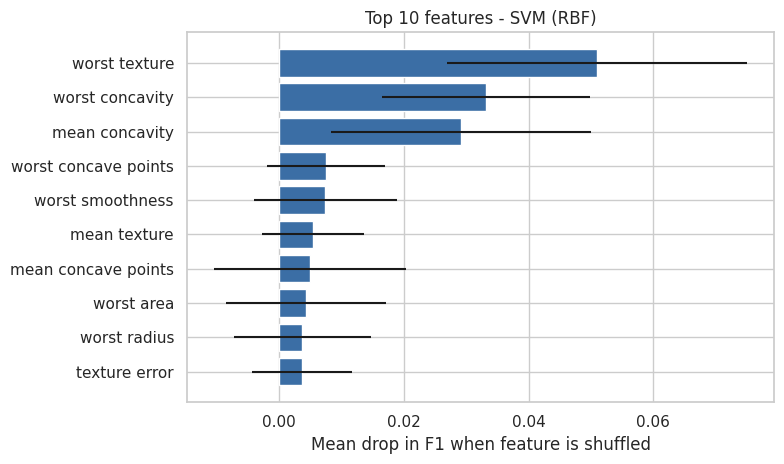

worst texture           0.0510
worst concavity         0.0332
mean concavity          0.0291
worst concave points    0.0075
worst smoothness        0.0074
mean texture            0.0055
mean concave points     0.0050
worst area              0.0043
worst radius            0.0037
texture error           0.0037
dtype: float64

In [16]:
pi = permutation_importance(best_model, X_test, y_test, scoring="f1", n_repeats=30,
                            random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(10)
err = pd.Series(pi.importances_std, index=X.columns)[imp.index]

plt.figure(figsize=(8, 4.8))
plt.barh(imp.index[::-1], imp.values[::-1], xerr=err.values[::-1], color="#3B6EA5")
plt.xlabel("Mean drop in F1 when feature is shuffled")
plt.title(f"Top 10 features - {best_name}")
plt.tight_layout()
plt.savefig(ROOT / "images" / "07_feature_importance.png", dpi=150)
plt.show()
imp.round(4)

## 10. Save the model and run a sample prediction

In [17]:
joblib.dump(best_model, ROOT / "models" / "best_model.joblib")

loaded = joblib.load(ROOT / "models" / "best_model.joblib")
sample = X_test.iloc[[0]]
p = loaded.predict_proba(sample)[0, 1]
print("True label       :", "malignant" if y_test.iloc[0] == 1 else "benign")
print("Predicted        :", "malignant" if p >= 0.5 else "benign")
print(f"P(malignant)     : {p:.3f}")

True label       : benign
Predicted        : benign
P(malignant)     : 0.000


## 11. Conclusion
* **Selected model: SVM (RBF kernel, C=10)**, chosen by the best cross-validated F1 on the training data (0.967).
* On the 114 unseen test samples it reached **accuracy 0.974, precision 1.000, recall 0.929, F1 0.963, ROC-AUC 0.993** (72 TN, 0 FP, 3 FN, 39 TP).
* All four algorithms performed within about 1 percentage point of each other in cross-validation (F1 between 0.946 and 0.964 before tuning). With only 114 test samples, one extra mistake moves accuracy by 0.9 points, so the ranking between the top models is **not statistically decisive**. Logistic Regression is nearly as good and far more interpretable.
* The remaining errors are 3 false negatives (missed malignancies). In a medical setting recall is the metric to improve, for example by lowering the decision threshold, at the cost of more false positives.
* Permutation importance shows that texture and concavity features carry the most signal. Many features are strongly correlated, so importance is shared between them and individual bars have wide error bars.
* **Limitation:** this is a small, clean research dataset. The model is a learning exercise and not a clinical tool.